In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("../1_Simple_Linear_Regression/placement.csv")

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


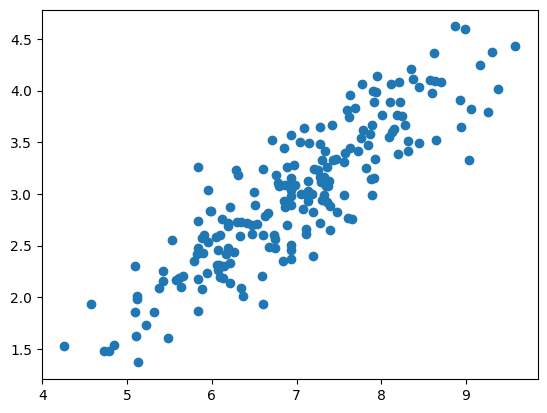

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.show()

In [11]:
X = df['cgpa']
y = df['package']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
print(X_train.shape)
print(X_train.to_frame().shape)

(160,)
(160, 1)


In [28]:
lr = LinearRegression()

In [29]:
lr.fit(X_train.to_frame(),y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = lr.predict(X_test.to_frame())

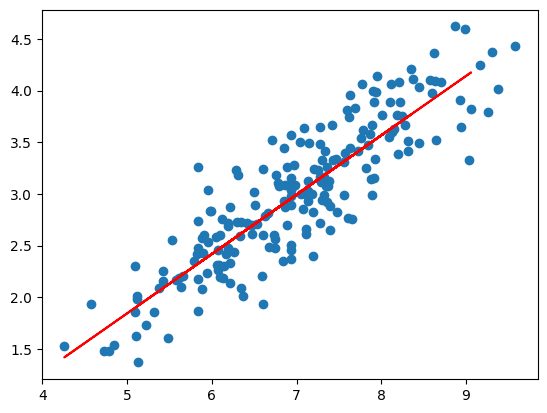

In [44]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_test,y_pred,'r')
plt.show()

In [45]:
m = lr.coef_

In [46]:
b = lr.intercept_

In [47]:
m

array([0.57425647])

In [48]:
b

np.float64(-1.0270069374542108)

In [49]:
mean_squared_error(y_test,y_pred)

0.08417638361329656

In [57]:
X_train.shape
y_train.shape

(160,)

In [58]:
class MeraLr:
    def __init__(self):
        self.coef_ = None # m / slope
        self.intercept_ = None # b

    def fit(self,X_train,y_train):
        num = 0
        den = 0

        Xmean = X_train.mean()
        ymean = y_train.mean()
        
        for i in range(X_train.shape[0]):
            num += (X_train[i] - Xmean) * (y_train[i] - ymean)
            den += (X_train[i] - Xmean) ** 2

        self.coef_ = num / den
        self.intercept_ = y_train.mean() - (self.coef_ * Xmean)

        print(self.coef_)
        print(self.intercept_)

    def predict(self,X_test):
        return self.intercept_ + self.coef_ * X_test

In [59]:
lr = MeraLr()

In [62]:
lr.fit(X_train.values,y_train.values)

0.5742564727019197
-1.0270069374542108


In [63]:
y_pred = lr.predict(X_test.values)

In [64]:
mean_squared_error(y_test,y_pred)

0.08417638361329656